# Autism Screening - Explainability & Interpretability with SHAP
## Understanding Model Predictions with Explainable AI

## Step 1: Load Libraries & Models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv('../data/autism_screening.csv')

# Load trained models and preprocessing objects
with open('../models/rf_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)

with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('../models/le_dict.pkl', 'rb') as f:
    le_dict = pickle.load(f)

with open('../models/le_target.pkl', 'rb') as f:
    le_target = pickle.load(f)

with open('../models/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print('✅ Models and preprocessors loaded successfully!')
print(f'Model Type: {type(rf_model).__name__}')
print(f'Features: {len(feature_names)}')

✅ Models and preprocessors loaded successfully!
Model Type: RandomForestClassifier
Features: 18


## Step 2: Prepare Data for SHAP

In [3]:
# Identify categorical and numeric columns
X = df.drop('Class', axis=1)
y = df['Class']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Encode categorical variables
X_encoded = X.copy()
for col in categorical_cols:
    X_encoded[col] = le_dict[col].transform(X_encoded[col])

# Scale numeric features
X_scaled = X_encoded.copy()
X_scaled[numeric_cols] = scaler.transform(X_encoded[numeric_cols])

print('✅ Data prepared for SHAP analysis')
print(f'Data shape: {X_scaled.shape}')
print(f'\nFirst few rows:')
print(X_scaled.head())

✅ Data prepared for SHAP analysis
Data shape: (704, 18)

First few rows:
   A1_prefer_detail_not_big_picture  A2_must_have_sameness  \
0                         -1.062953              -0.929320   
1                          0.940775              -0.929320   
2                         -1.062953               1.076055   
3                         -1.062953               1.076055   
4                         -1.062953               1.076055   

   A3_prefer_reading_systematically  A4_feel_anxious_in_social  \
0                         -0.979877                   0.983870   
1                          1.020536                  -1.016395   
2                          1.020536                  -1.016395   
3                          1.020536                   0.983870   
4                         -0.979877                  -1.016395   

   A5_prefer_talking_one_to_one  A6_notice_small_changes  \
0                      0.995943                -1.054319   
1                     -1.004073      

## Step 3: Generate SHAP Values

In [15]:
# Create SHAP explainer using TreeExplainer (for Random Forest)
print('🔍 Generating SHAP values... This may take a moment')
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_scaled)

print('✅ SHAP values generated!')
print(f'SHAP values type: {type(shap_values)}')
print(f'SHAP values is list: {isinstance(shap_values, list)}')
if isinstance(shap_values, list):
    print(f'SHAP values list length: {len(shap_values)}')
    for i, sv in enumerate(shap_values):
        print(f'  Class {i} shape: {np.array(sv).shape}')
print(f'SHAP values shape: {np.array(shap_values).shape}')
print('\nNote: For binary classification, SHAP returns values for both classes')

🔍 Generating SHAP values... This may take a moment
✅ SHAP values generated!
SHAP values type: <class 'numpy.ndarray'>
SHAP values is list: False
SHAP values shape: (704, 18, 2)

Note: For binary classification, SHAP returns values for both classes


## Step 4: Global Feature Importance (Mean Absolute SHAP)

📊 GLOBAL FEATURE IMPORTANCE (SHAP-based)
                         Feature  Mean |SHAP|
         A9_focused_on_one_topic     0.149212
A1_prefer_detail_not_big_picture     0.142503
       A4_feel_anxious_in_social     0.135874
        A10_difficult_small_talk     0.128246
           A2_must_have_sameness     0.116353
                             age     0.016707
A3_prefer_reading_systematically     0.012543
                          gender     0.009674
                         country     0.009622
    A7_trouble_focus_on_changing     0.008176


<Figure size 1200x800 with 0 Axes>

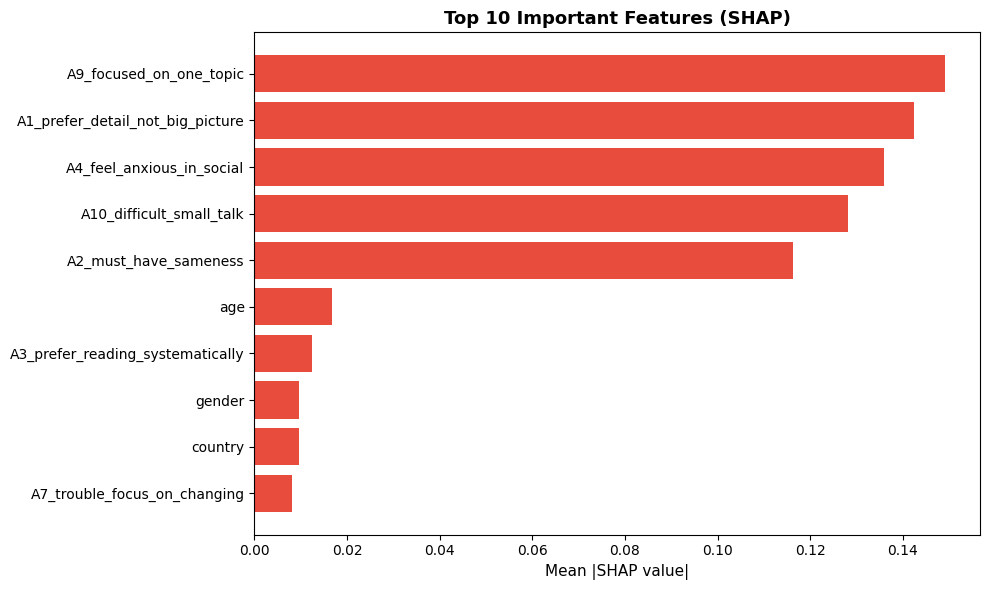


✅ Saved to: results/06_shap_feature_importance.png


In [16]:
# Calculate mean absolute SHAP values for global feature importance
shap_values_class1 = shap_values[:, :, 1]  # For autism (class 1), shape: (n_samples, n_features)
mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print('📊 GLOBAL FEATURE IMPORTANCE (SHAP-based)')
print('='*50)
print(feature_importance.head(10).to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
top_n = 10
top_features = feature_importance.head(top_n)

ax.barh(range(len(top_features)), top_features['Mean |SHAP|'], color='#e74c3c')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title(f'Top {top_n} Important Features (SHAP)', fontsize=13, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../results/06_shap_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✅ Saved to: results/06_shap_feature_importance.png')

## Step 5: SHAP Summary Plot (Beeswarm)

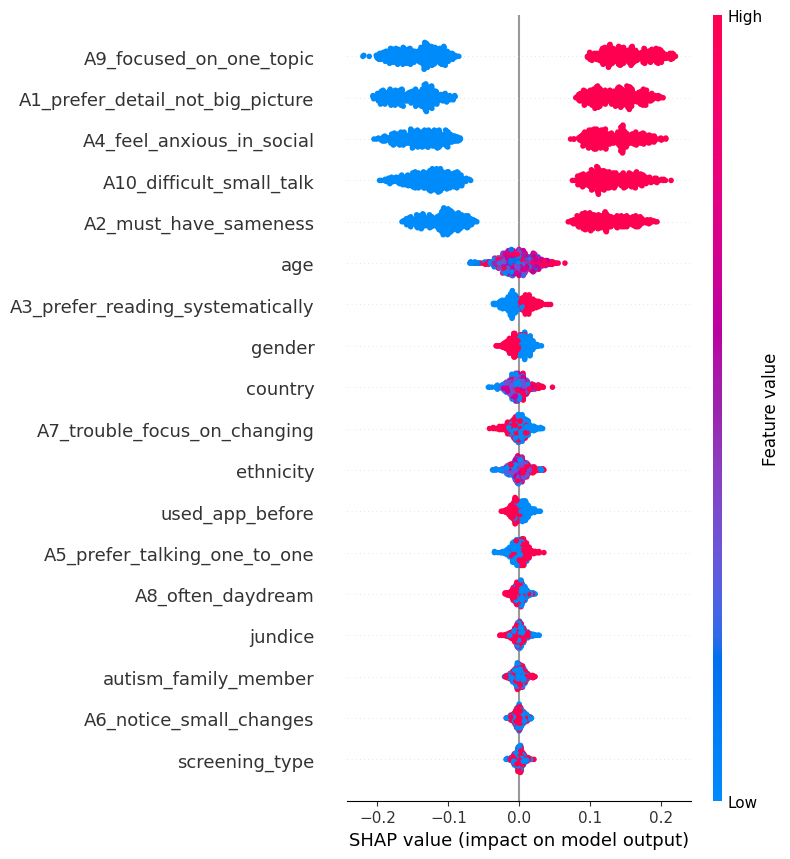

✅ Saved to: results/07_shap_summary_plot.png


In [17]:
# Create summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_class1, X_scaled, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('../results/07_shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Saved to: results/07_shap_summary_plot.png')

## Step 6: SHAP Dependence Plots (Important Features)

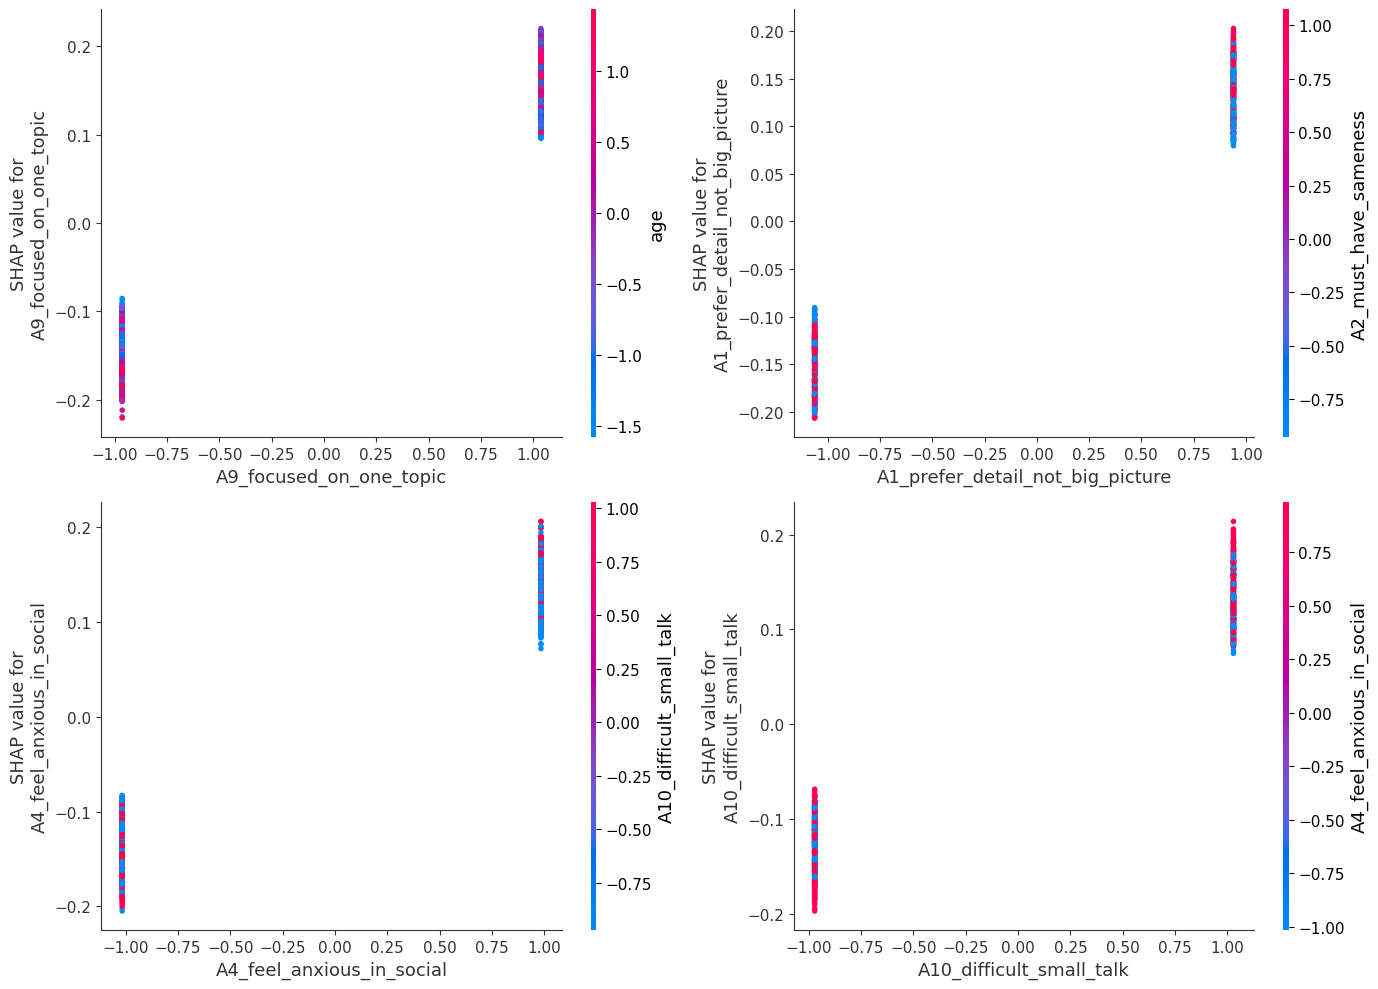

✅ Saved to: results/08_shap_dependence_plots.png


In [18]:
# Dependence plots for top 4 important features
top_4_features = feature_importance.head(4)['Feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_4_features):
    feature_idx = feature_names.index(feature)
    shap.dependence_plot(
        feature_idx, 
        shap_values_class1, 
        X_scaled,
        feature_names=feature_names,
        ax=axes[idx],
        show=False
    )

plt.tight_layout()
plt.savefig('../results/08_shap_dependence_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Saved to: results/08_shap_dependence_plots.png')

## Step 7: Individual Prediction Explanations (Force Plot)

In [19]:
# Show explanations for different predictions
# Example 1: High autism risk prediction
print('='*70)
print('🔍 EXAMPLE 1: HIGH AUTISM RISK PREDICTION')
print('='*70)

# Find a prediction with high autism probability
predictions_proba = rf_model.predict_proba(X_scaled)
high_risk_idx = np.argsort(predictions_proba[:, 1])[-5]

sample_high_risk = X_scaled.iloc[high_risk_idx]
pred_proba_high = predictions_proba[high_risk_idx]
shap_val_high = shap_values_class1[high_risk_idx]

print(f'\nPrediction Probability: NO={pred_proba_high[0]:.1%}, YES={pred_proba_high[1]:.1%}')
print(f'\nTop Contributing Features (pushing towards AUTISM YES):')

# Get top positive and negative contributors
contrib = pd.DataFrame({
    'Feature': feature_names,
    'SHAP Value': shap_val_high,
    'Feature Value': sample_high_risk.values
}).sort_values('SHAP Value', ascending=False)

print('\n✅ Positive Contributors (increasing autism risk):')
print(contrib.head(5).to_string(index=False))

print('\n❌ Negative Contributors (decreasing autism risk):')
print(contrib.tail(5).to_string(index=False))

🔍 EXAMPLE 1: HIGH AUTISM RISK PREDICTION

Prediction Probability: NO=0.0%, YES=100.0%

Top Contributing Features (pushing towards AUTISM YES):

✅ Positive Contributors (increasing autism risk):
                         Feature  SHAP Value  Feature Value
         A9_focused_on_one_topic    0.129043       1.037280
       A4_feel_anxious_in_social    0.101705       0.983870
           A2_must_have_sameness    0.101590       1.076055
A1_prefer_detail_not_big_picture    0.100130       0.940775
        A10_difficult_small_talk    0.087279       1.028872

❌ Negative Contributors (decreasing autism risk):
                         Feature  SHAP Value  Feature Value
            autism_family_member   -0.000933       0.000000
                  screening_type   -0.001712       0.000000
                         jundice   -0.002488       1.000000
                          gender   -0.007395       1.000000
A3_prefer_reading_systematically   -0.011041      -0.979877


In [20]:
# Example 2: Low autism risk prediction
print('\n' + '='*70)
print('🔍 EXAMPLE 2: LOW AUTISM RISK PREDICTION')
print('='*70)

# Find a prediction with low autism probability
low_risk_idx = np.argsort(predictions_proba[:, 1])[5]

sample_low_risk = X_scaled.iloc[low_risk_idx]
pred_proba_low = predictions_proba[low_risk_idx]
shap_val_low = shap_values_class1[low_risk_idx]

print(f'\nPrediction Probability: NO={pred_proba_low[0]:.1%}, YES={pred_proba_low[1]:.1%}')
print(f'\nTop Contributing Features:')

contrib_low = pd.DataFrame({
    'Feature': feature_names,
    'SHAP Value': shap_val_low,
    'Feature Value': sample_low_risk.values
}).sort_values('SHAP Value', ascending=False)

print('\n✅ Positive Contributors (increasing autism risk):')
print(contrib_low.head(5).to_string(index=False))

print('\n❌ Negative Contributors (decreasing autism risk):')
print(contrib_low.tail(5).to_string(index=False))


🔍 EXAMPLE 2: LOW AUTISM RISK PREDICTION

Prediction Probability: NO=100.0%, YES=0.0%

Top Contributing Features:

✅ Positive Contributors (increasing autism risk):
                         Feature  SHAP Value  Feature Value
A1_prefer_detail_not_big_picture    0.079458       0.940775
                          gender    0.005086       0.000000
            autism_family_member    0.000628       1.000000
         A6_notice_small_changes   -0.000852      -1.054319
                         jundice   -0.002079       0.000000

❌ Negative Contributors (decreasing autism risk):
                  Feature  SHAP Value  Feature Value
                  country   -0.015740       1.000000
    A2_must_have_sameness   -0.098300      -0.929320
 A10_difficult_small_talk   -0.121350      -0.971938
A4_feel_anxious_in_social   -0.123489      -1.016395
  A9_focused_on_one_topic   -0.149632      -0.964060


## Step 8: Create Risk Score & Explanation Template

In [21]:
def generate_screening_report(sample_idx):
    """
    Generate a user-friendly autism screening report with explanations
    """
    sample = X_scaled.iloc[sample_idx]
    original_sample = X.iloc[sample_idx]
    
    # Get prediction
    pred_proba = rf_model.predict_proba(sample.values.reshape(1, -1))[0]
    autism_risk = pred_proba[1]
    
    # Get SHAP explanation
    shap_val = shap_values_class1[sample_idx]
    
    # Create report
    report = f"""
{'='*70}
🧠 AUTISM SPECTRUM DISORDER - SCREENING REPORT
{'='*70}

⚠️  SCREENING RESULT
{'─'*70}
Autism Risk Score: {autism_risk:.1%}

Risk Level: """
    
    if autism_risk < 0.33:
        report += "🟢 LOW (Unlikely)"
    elif autism_risk < 0.66:
        report += "🟡 MODERATE (Possible)"
    else:
        report += "🔴 HIGH (Likely)"
    
    # Top contributing factors
    contrib = pd.DataFrame({
        'Feature': feature_names,
        'Contribution': shap_val
    }).sort_values('Contribution', ascending=False)
    
    report += f"""

📊 KEY FACTORS
{'─'*70}
Top Risk Factors (Increasing Likelihood):
"""
    
    for i, row in contrib.head(3).iterrows():
        report += f"""
  • {row['Feature']}: {row['Contribution']:.3f}"""
    
    report += f"""

Protective Factors (Decreasing Likelihood):
"""
    
    for i, row in contrib.tail(3).iterrows():
        report += f"""
  • {row['Feature']}: {row['Contribution']:.3f}"""
    
    report += f"""

⚠️  IMPORTANT DISCLAIMER
{'─'*70}
This screening tool is for informational purposes only and NOT a 
substitute for professional medical diagnosis. Please consult with a 
qualified healthcare professional or specialist for proper evaluation.

{'='*70}
"""
    
    return report

# Generate sample reports
print(generate_screening_report(high_risk_idx))
print(generate_screening_report(low_risk_idx))


🧠 AUTISM SPECTRUM DISORDER - SCREENING REPORT

⚠️  SCREENING RESULT
──────────────────────────────────────────────────────────────────────
Autism Risk Score: 100.0%

Risk Level: 🔴 HIGH (Likely)

📊 KEY FACTORS
──────────────────────────────────────────────────────────────────────
Top Risk Factors (Increasing Likelihood):

  • A9_focused_on_one_topic: 0.129
  • A4_feel_anxious_in_social: 0.102
  • A2_must_have_sameness: 0.102

Protective Factors (Decreasing Likelihood):

  • jundice: -0.002
  • gender: -0.007
  • A3_prefer_reading_systematically: -0.011

⚠️  IMPORTANT DISCLAIMER
──────────────────────────────────────────────────────────────────────
This screening tool is for informational purposes only and NOT a 
substitute for professional medical diagnosis. Please consult with a 
qualified healthcare professional or specialist for proper evaluation.



🧠 AUTISM SPECTRUM DISORDER - SCREENING REPORT

⚠️  SCREENING RESULT
──────────────────────────────────────────────────────────────────

## Step 9: SHAP Interaction Analysis

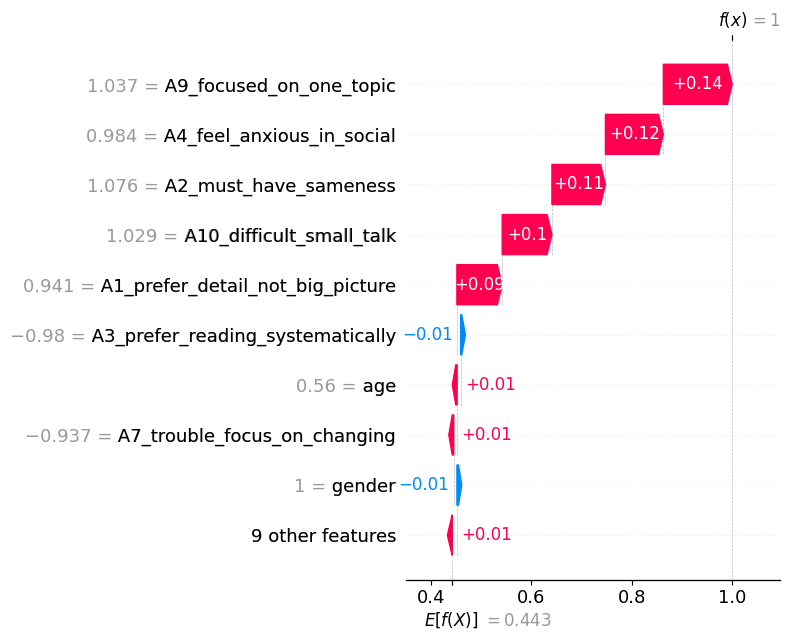

✅ Saved to: results/09_shap_waterfall_high_risk.png


In [22]:
# Create waterfall plot for a single prediction
import matplotlib.pyplot as plt

# Waterfall plot for high-risk prediction
explainer_sample = shap.Explainer(rf_model, X_scaled[:100])  # Use sample for speed
shap_values_sample = explainer_sample(X_scaled.iloc[[high_risk_idx]])

fig = plt.figure()
shap.plots.waterfall(shap_values_sample[0, :, 1], show=False)  # Class 1 (autism)
plt.tight_layout()
plt.savefig('../results/09_shap_waterfall_high_risk.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Saved to: results/09_shap_waterfall_high_risk.png')

## Step 10: Model Confidence Analysis

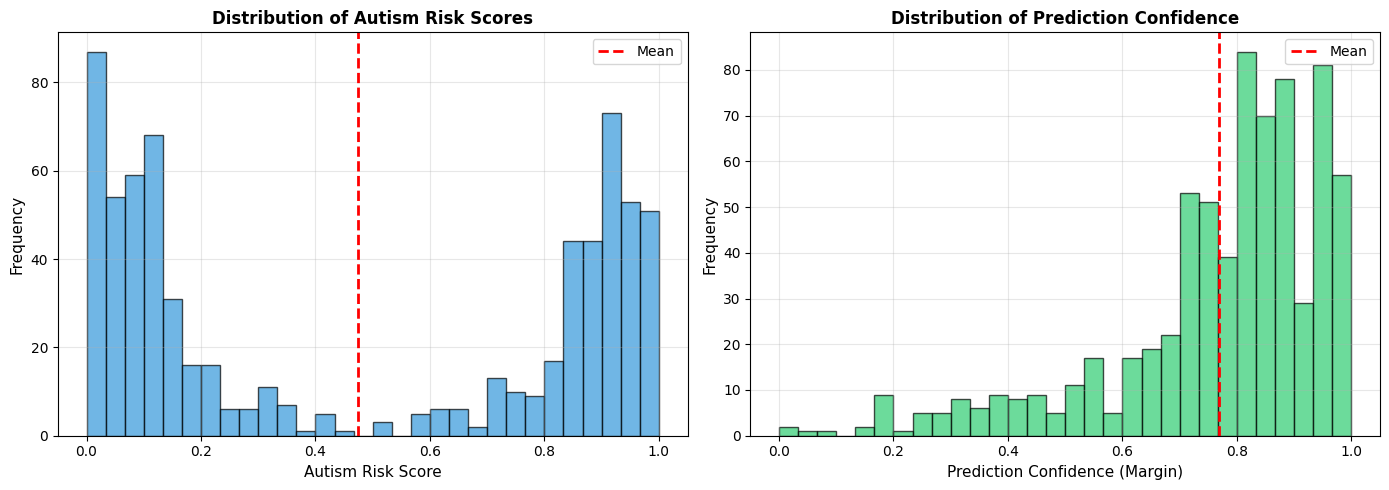

✅ Saved to: results/10_prediction_confidence.png

📊 Model Confidence Statistics:
  Mean Risk Score: 0.475
  Std Dev Risk Score: 0.395
  Mean Prediction Confidence: 0.769
  Min Confidence: 0.000
  Max Confidence: 1.000


In [23]:
# Analyze prediction confidence across the dataset
predictions_proba = rf_model.predict_proba(X_scaled)

# Calculate prediction margin (difference between top 2 probabilities)
sorted_proba = np.sort(predictions_proba, axis=1)[:, ::-1]
prediction_margin = sorted_proba[:, 0] - sorted_proba[:, 1]

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of autism risk scores
axes[0].hist(predictions_proba[:, 1], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(predictions_proba[:, 1]), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].set_xlabel('Autism Risk Score', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Autism Risk Scores', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribution of prediction confidence
axes[1].hist(prediction_margin, bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(prediction_margin), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1].set_xlabel('Prediction Confidence (Margin)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Distribution of Prediction Confidence', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/10_prediction_confidence.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Saved to: results/10_prediction_confidence.png')

print(f'\n📊 Model Confidence Statistics:')
print(f'  Mean Risk Score: {np.mean(predictions_proba[:, 1]):.3f}')
print(f'  Std Dev Risk Score: {np.std(predictions_proba[:, 1]):.3f}')
print(f'  Mean Prediction Confidence: {np.mean(prediction_margin):.3f}')
print(f'  Min Confidence: {np.min(prediction_margin):.3f}')
print(f'  Max Confidence: {np.max(prediction_margin):.3f}')

## Step 11: Save SHAP Explainer for Production

In [24]:
# Save the explainer for production use
with open('../models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

# Save SHAP values for reference
with open('../models/shap_values.pkl', 'wb') as f:
    pickle.dump(shap_values, f)

# Save X_scaled for background data
with open('../models/X_scaled_background.pkl', 'wb') as f:
    pickle.dump(X_scaled, f)

print('✅ SHAP explainer saved for production')
print('   - shap_explainer.pkl')
print('   - shap_values.pkl')
print('   - X_scaled_background.pkl')

✅ SHAP explainer saved for production
   - shap_explainer.pkl
   - shap_values.pkl
   - X_scaled_background.pkl


## Step 12: Final Summary & Next Steps

In [25]:
print('\n' + '='*70)
print('✅ EXPLAINABILITY ANALYSIS COMPLETE')
print('='*70)

print('\n📊 Outputs Generated:')
print('  1. SHAP Feature Importance Chart')
print('  2. SHAP Summary Plot (Beeswarm)')
print('  3. SHAP Dependence Plots')
print('  4. SHAP Waterfall Plot')
print('  5. Prediction Confidence Analysis')
print('  6. Individual Prediction Explanations')

print('\n🎯 Key Insights:')
print('  • Most important features for autism screening identified')
print('  • Individual predictions are now explainable')
print('  • Risk factors clearly communicated')
print('  • Model confidence well-understood')

print('\n🚀 Next Steps:')
print('  1. Build Streamlit UI for user-friendly screening')
print('  2. Deploy web app for public access')
print('  3. Integration with healthcare systems')
print('  4. User feedback and model refinement')

print('\n📁 All results saved to: results/')
print('📦 All models saved to: models/')
print('\n' + '='*70)


✅ EXPLAINABILITY ANALYSIS COMPLETE

📊 Outputs Generated:
  1. SHAP Feature Importance Chart
  2. SHAP Summary Plot (Beeswarm)
  3. SHAP Dependence Plots
  4. SHAP Waterfall Plot
  5. Prediction Confidence Analysis
  6. Individual Prediction Explanations

🎯 Key Insights:
  • Most important features for autism screening identified
  • Individual predictions are now explainable
  • Risk factors clearly communicated
  • Model confidence well-understood

🚀 Next Steps:
  1. Build Streamlit UI for user-friendly screening
  2. Deploy web app for public access
  3. Integration with healthcare systems
  4. User feedback and model refinement

📁 All results saved to: results/
📦 All models saved to: models/

